In [14]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [15]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [17]:
ts = pd.read_csv('MOD-00682.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29T14:23:31Z,17.845,2.898,0.659,0.067,0.099,0.060,7.854,821.109,-13.269,2.480,31.895,82.0,9.5
1,2025-12-29T14:22:31Z,19.233,3.362,0.798,0.113,0.093,0.069,8.175,834.585,-12.529,2.476,31.417,82.1,9.5
2,2025-12-29T14:21:31Z,19.714,3.435,0.946,0.105,0.115,0.050,8.075,841.351,-13.787,2.480,31.168,82.4,9.5
3,2025-12-29T14:20:31Z,20.809,3.720,0.963,0.134,0.150,0.069,9.191,854.061,-13.597,2.764,31.617,83.0,9.5
4,2025-12-29T14:19:31Z,22.045,4.229,1.090,0.171,0.086,0.080,7.749,866.432,-14.149,2.766,32.069,83.5,9.5


In [18]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29 14:23:31,17.845,2.898,0.659,0.067,0.099,0.060,7.854,821.109,-13.269,2.480,31.895,82.0,9.5
1,2025-12-29 14:22:31,19.233,3.362,0.798,0.113,0.093,0.069,8.175,834.585,-12.529,2.476,31.417,82.1,9.5
2,2025-12-29 14:21:31,19.714,3.435,0.946,0.105,0.115,0.050,8.075,841.351,-13.787,2.480,31.168,82.4,9.5
3,2025-12-29 14:20:31,20.809,3.720,0.963,0.134,0.150,0.069,9.191,854.061,-13.597,2.764,31.617,83.0,9.5
4,2025-12-29 14:19:31,22.045,4.229,1.090,0.171,0.086,0.080,7.749,866.432,-14.149,2.766,32.069,83.5,9.5


## Full Timeseries Plot

In [19]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,29.683238,5.957946,1.825933,0.509283,0.668317,0.578937,10.105787,918.556896,15.230979,2.534825,37.361304,86.865833,15.974167
2025-04-01,5.473266,0.917626,0.258826,0.052505,0.053141,0.032705,2.648759,651.838859,26.787015,2.168222,27.934783,45.846111,11.885625
2025-04-02,3.782124,0.667889,0.371102,0.138726,0.194005,0.159955,3.898557,701.213787,26.614278,1.968441,33.709867,43.156250,7.660278
2025-04-03,22.142930,3.417667,1.155309,0.392961,0.582105,0.516767,12.230746,888.011051,18.001438,2.220334,28.827374,78.088333,15.620694
2025-04-04,5.052384,0.595769,0.216154,0.058294,0.079674,0.057992,4.195192,732.538001,31.128056,2.082364,20.506994,44.888750,20.666944


In [ ]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15,2.625027,0.302952,0.119215,0.033442,0.048540,0.033744,5.388944,760.058277,59.020083,2.451980,17.703737,35.317241,17.787533,6.180249
2025-04-16,0.840658,0.090576,0.030162,0.006452,0.008266,0.005517,0.495880,726.209739,52.386164,2.143281,15.912844,38.811111,10.336458,2.676057
2025-04-17,2.574542,0.259308,0.093874,0.022390,0.028447,0.018033,3.291242,779.538718,54.347578,2.147835,18.649936,30.430764,14.200417,4.950538
2025-04-18,7.015260,1.175359,0.531528,0.158738,0.201063,0.146458,11.160694,945.526915,50.311835,9.476236,28.108258,36.153472,15.887292,9.332457
2025-04-19,11.997442,1.266906,0.563967,0.186564,0.255871,0.202708,25.792534,825.706856,54.770118,2.742736,20.201353,49.177292,23.107083,17.653663


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_202/514874767.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


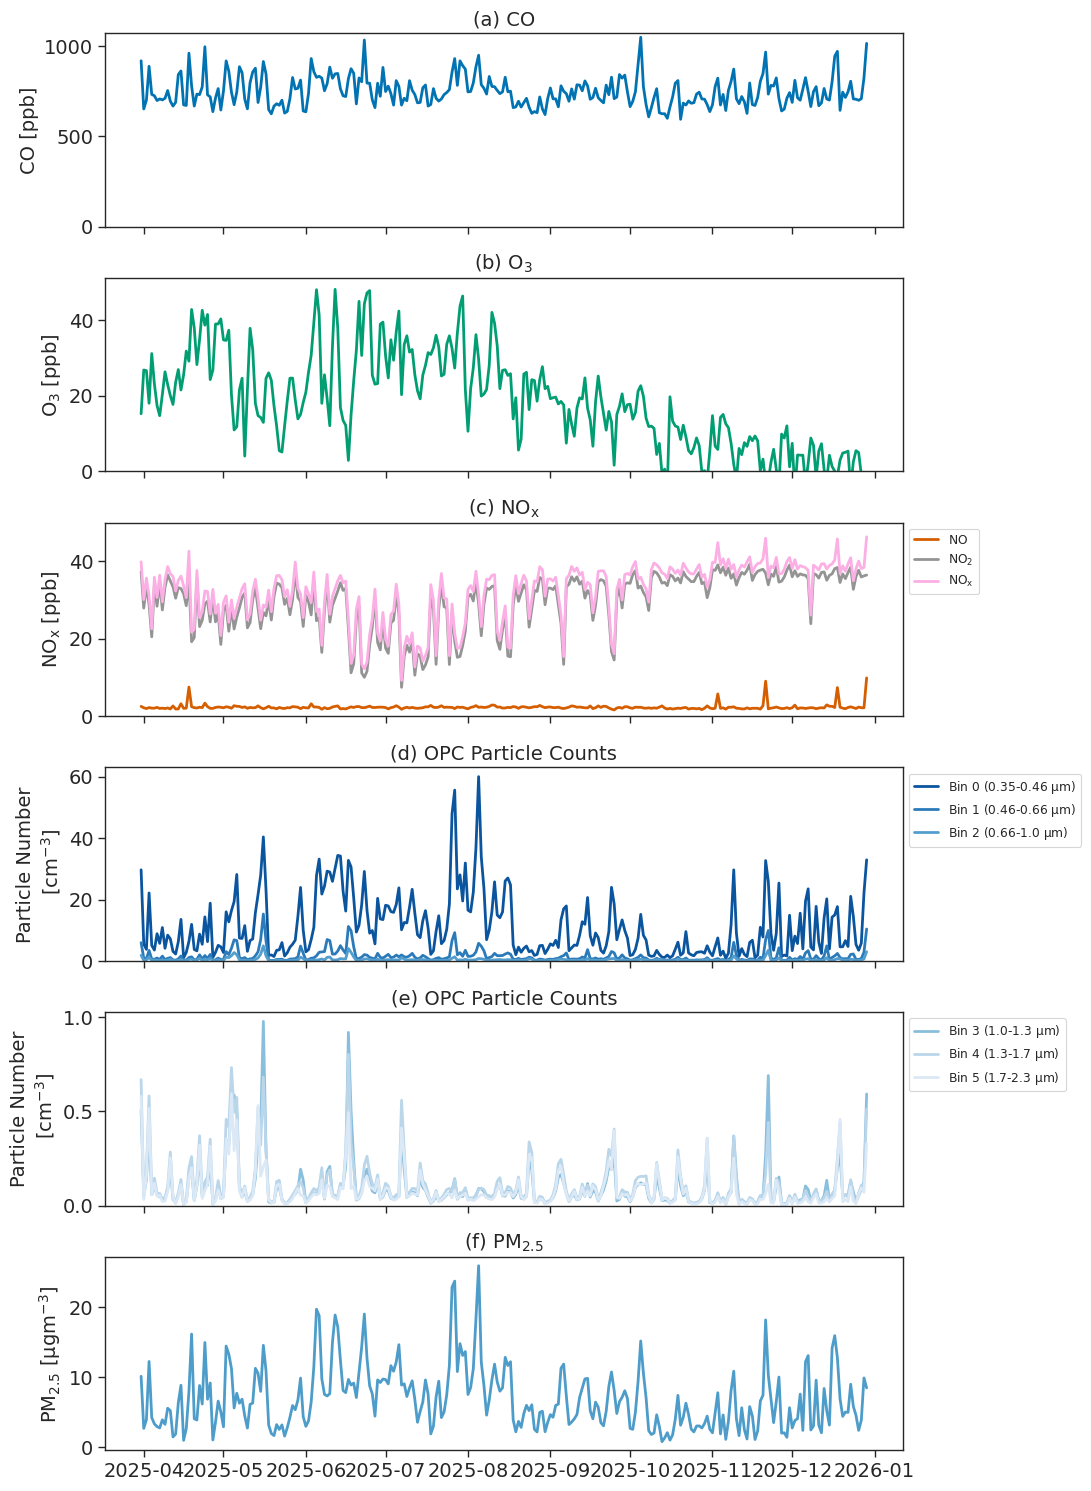

In [20]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

# fig.savefig('timeseries_MOD-00682.png')

## Dirunal Plots

In [21]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,25.402567,2.886100,1.343567,0.474767,0.674100,0.588500,10.719217,869.259750,13.002950,1.995733,37.013050,81.615000,15.728333
2025-03-31 21:00:00,34.534917,5.526633,1.912233,0.594317,0.827650,0.762517,12.612750,909.419417,10.867517,2.526033,39.488533,87.193333,15.631667
2025-03-31 22:00:00,36.650450,9.721950,2.585483,0.641217,0.810067,0.693800,11.158750,1066.794067,11.799100,2.832617,41.319733,90.258333,16.183333
2025-03-31 23:00:00,22.145017,5.697100,1.462450,0.326833,0.361450,0.270933,5.932433,828.754350,25.254350,2.784917,31.623900,88.396667,16.353333
2025-04-01 00:00:00,17.505233,3.568650,0.952217,0.209067,0.241983,0.165317,5.468583,716.476567,31.260017,2.512533,29.669083,85.396667,16.075000


In [22]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,25.402567,2.886100,1.343567,0.474767,0.674100,0.588500,10.719217,869.259750,13.002950,1.995733,37.013050,81.615000,15.728333,8.050503
2025-03-31 21:00:00,34.534917,5.526633,1.912233,0.594317,0.827650,0.762517,12.612750,909.419417,10.867517,2.526033,39.488533,87.193333,15.631667,8.743823
2025-03-31 22:00:00,36.650450,9.721950,2.585483,0.641217,0.810067,0.693800,11.158750,1066.794067,11.799100,2.832617,41.319733,90.258333,16.183333,8.411674
2025-03-31 23:00:00,22.145017,5.697100,1.462450,0.326833,0.361450,0.270933,5.932433,828.754350,25.254350,2.784917,31.623900,88.396667,16.353333,6.818052
2025-04-01 00:00:00,17.505233,3.568650,0.952217,0.209067,0.241983,0.165317,5.468583,716.476567,31.260017,2.512533,29.669083,85.396667,16.075000,6.593908


In [23]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,25.402567,2.886100,1.343567,0.474767,0.674100,0.588500,10.719217,869.259750,13.002950,1.995733,37.013050,81.615000,15.728333,8.050503,20
2025-03-31 21:00:00,34.534917,5.526633,1.912233,0.594317,0.827650,0.762517,12.612750,909.419417,10.867517,2.526033,39.488533,87.193333,15.631667,8.743823,21
2025-03-31 22:00:00,36.650450,9.721950,2.585483,0.641217,0.810067,0.693800,11.158750,1066.794067,11.799100,2.832617,41.319733,90.258333,16.183333,8.411674,22
2025-03-31 23:00:00,22.145017,5.697100,1.462450,0.326833,0.361450,0.270933,5.932433,828.754350,25.254350,2.784917,31.623900,88.396667,16.353333,6.818052,23
2025-04-01 00:00:00,17.505233,3.568650,0.952217,0.209067,0.241983,0.165317,5.468583,716.476567,31.260017,2.512533,29.669083,85.396667,16.075000,6.593908,0


In [24]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,11.712143,2.037613,0.592769,0.129579,0.136949,0.096316,6.906401,774.363893,13.139187,2.149044,32.120663,62.968171,16.727318,6.516709
01:00,11.715760,1.890638,0.520088,0.112963,0.124328,0.092544,6.732653,750.723360,12.273564,2.152829,32.189140,64.337051,16.394804,6.481160
02:00,11.732818,1.807764,0.493684,0.109026,0.122414,0.093315,6.575465,740.227161,11.217036,2.253471,32.013880,65.720087,16.055620,6.450552
03:00,11.812782,1.804867,0.486245,0.107799,0.121401,0.093186,6.423676,726.883760,10.074735,2.164271,31.804057,66.851916,15.697053,6.414554
04:00,12.120332,1.962383,0.540903,0.120778,0.131781,0.096847,6.430170,730.599734,8.791128,2.125455,32.323442,68.005670,15.386766,6.428665
05:00,12.552591,2.095336,0.590503,0.133120,0.142962,0.104431,6.540071,761.453456,7.377372,2.205742,32.624606,68.967428,15.162591,6.473289
06:00,12.471125,2.013424,0.560545,0.128179,0.140381,0.104052,6.642081,785.068465,7.161452,2.263058,32.765748,68.414056,15.192022,6.491878
07:00,12.357024,1.870871,0.516003,0.120539,0.139173,0.106124,7.003319,795.861053,9.480188,2.953889,30.064947,64.762505,16.223921,6.563485
08:00,11.977118,1.710333,0.460523,0.103914,0.124676,0.094643,7.204847,775.548206,13.436658,2.782240,26.887572,59.171082,17.971568,6.576729


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_202/3903957172.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_202/3903957172.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r

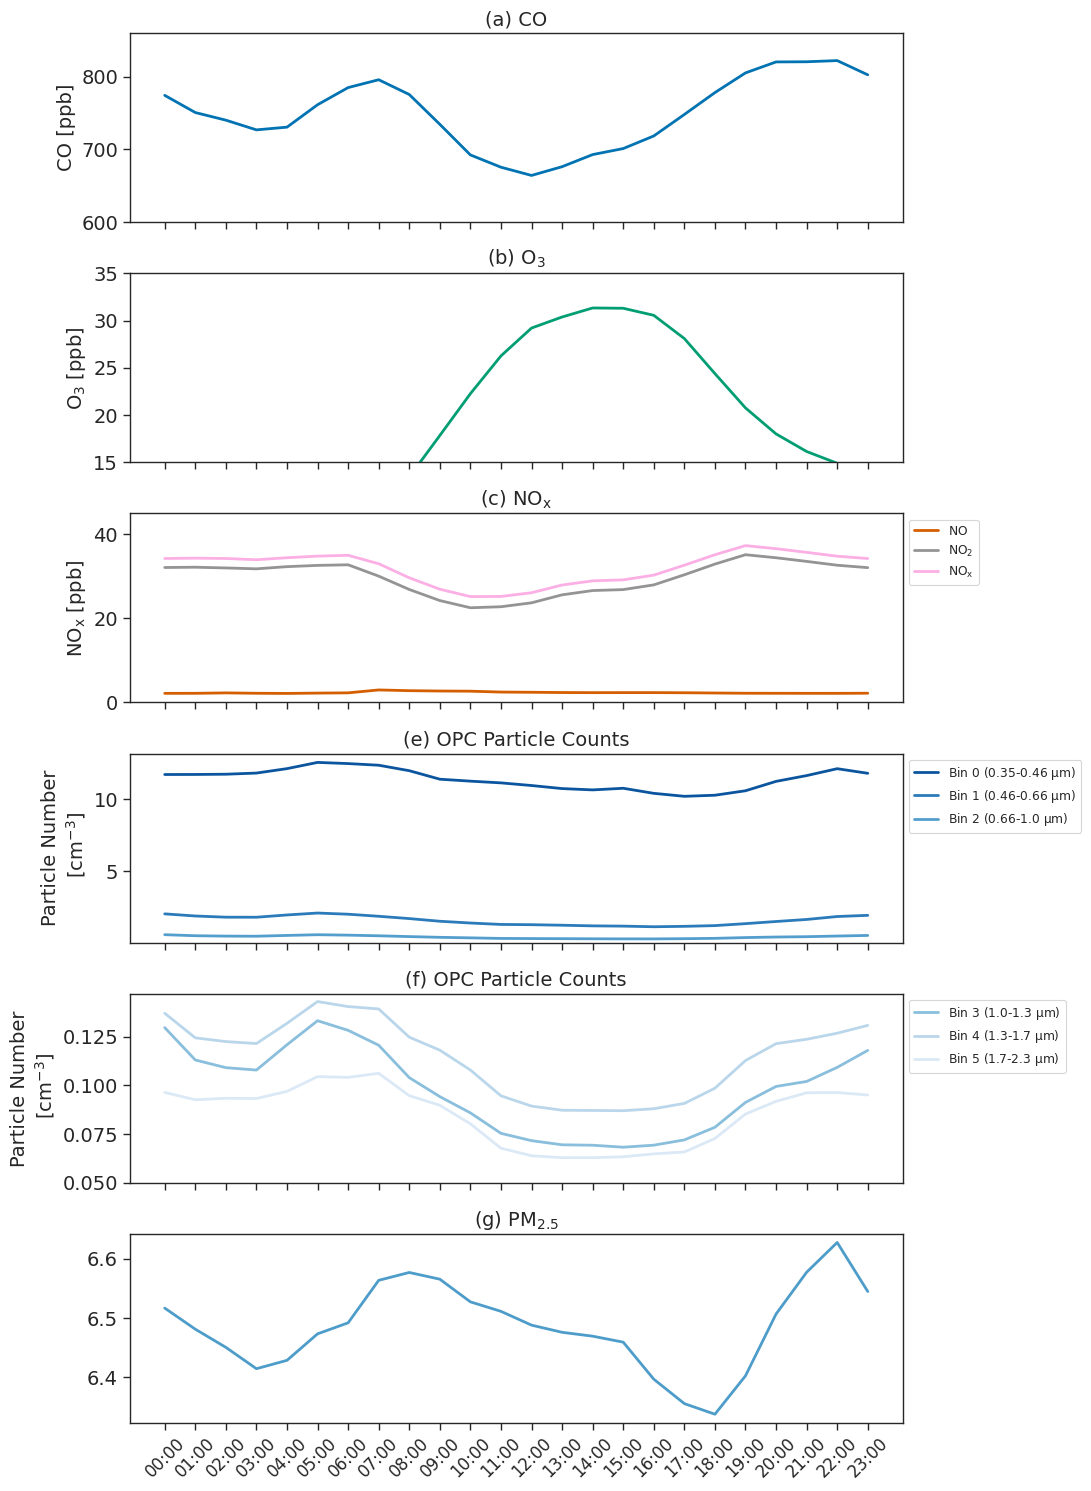

In [26]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(600, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(15, 35)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 45)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

# fig.savefig('dirunal_MOD-00682_allfeatures.png')

## Diurnal by Season

In [27]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [28]:
ts_hour = ts_hour.reset_index()

In [29]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,25.402567,2.886100,1.343567,0.474767,0.674100,0.588500,10.719217,869.259750,13.002950,1.995733,37.013050,81.615000,15.728333,8.050503,20,Spring
1,2025-03-31 21:00:00,34.534917,5.526633,1.912233,0.594317,0.827650,0.762517,12.612750,909.419417,10.867517,2.526033,39.488533,87.193333,15.631667,8.743823,21,Spring
2,2025-03-31 22:00:00,36.650450,9.721950,2.585483,0.641217,0.810067,0.693800,11.158750,1066.794067,11.799100,2.832617,41.319733,90.258333,16.183333,8.411674,22,Spring
3,2025-03-31 23:00:00,22.145017,5.697100,1.462450,0.326833,0.361450,0.270933,5.932433,828.754350,25.254350,2.784917,31.623900,88.396667,16.353333,6.818052,23,Spring
4,2025-04-01 00:00:00,17.505233,3.568650,0.952217,0.209067,0.241983,0.165317,5.468583,716.476567,31.260017,2.512533,29.669083,85.396667,16.075000,6.593908,0,Spring


In [30]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      6.553875  1.231214  0.434220  0.102961  0.110172  0.076676   
       1      6.917851  1.055341  0.330481  0.077091  0.091205  0.074114   
       2      7.289161  1.076213  0.334901  0.080668  0.097498  0.079893   
       3      7.671981  1.101963  0.339055  0.082299  0.099502  0.081638   
       4      8.144455  1.297792  0.395612  0.091888  0.102387  0.077744   
...                ...       ...       ...       ...       ...       ...   
Winter 19    10.933765  1.352798  0.358782  0.071167  0.069342  0.048093   
       20    11.235286  1.424420  0.376069  0.073670  0.070423  0.048326   
       21    11.386655  1.541029  0.410064  0.081310  0.075626  0.051504   
       22    12.636106  1.961058  0.499896  0.104022  0.100551  0.066664   
       23    14.189356  2.511230  0.641277  0.130168  0.127604  0.090132   

                 pm25          co        o3        no        no2         rh  \
Season Hour                                                                   
Autumn 0     5.110225  738.525752  7.384552  2.145515  34.850397  61.845216   
       1     5.122854  732.347966  6.173046  2.187443  35.280552  63.909721   
       2     5.185261  737.068766  5.002248  2.542735  35.064337  65.799330   
       3     5.195057  727.829965  3.984033  2.318263  35.313746  67.193242   
       4     5.082377  725.492128  2.910608  2.279767  35.912179  68.409119   
...               ...         ...       ...       ...        ...        ...   
Winter 19    6.513789  766.722209  1.507993  2.105748  36.915267  56.730238   
       20    6.708154  778.055559  0.993896  2.191285  36.781592  57.382798   
       21    6.720616  760.453129  0.797068  2.182268  36.570964  57.824940   
       22    7.087432  761.132607  0.292784  2.229837  37.037543  59.521012   
       23    7.475403  768.023876 -0.498136  2.275192  37.303491  61.137917   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.288574  5.882561  
       1     14.954266  5.919157  
       2     14.633027  5.967043  
       3     14.287420  5.986136  
       4     13.990268  5.966881  
...                ...       ...  
Winter 19     2.281369  5.527703  
       20     2.037143  5.589074  
       21     1.900952  5.596590  
       22     1.768750  5.739996  
       23     1.566964  5.884328  

[96 rows x 14 columns]

In [31]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,6.553875,1.231214,0.434220,0.102961,0.110172,0.076676,5.110225,738.525752,7.384552,2.145515,34.850397,61.845216,15.288574,5.882561
1,Autumn,1,6.917851,1.055341,0.330481,0.077091,0.091205,0.074114,5.122854,732.347966,6.173046,2.187443,35.280552,63.909721,14.954266,5.919157
2,Autumn,2,7.289161,1.076213,0.334901,0.080668,0.097498,0.079893,5.185261,737.068766,5.002248,2.542735,35.064337,65.799330,14.633027,5.967043
3,Autumn,3,7.671981,1.101963,0.339055,0.082299,0.099502,0.081638,5.195057,727.829965,3.984033,2.318263,35.313746,67.193242,14.287420,5.986136
4,Autumn,4,8.144455,1.297792,0.395612,0.091888,0.102387,0.077744,5.082377,725.492128,2.910608,2.279767,35.912179,68.409119,13.990268,5.966881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,10.933765,1.352798,0.358782,0.071167,0.069342,0.048093,6.513789,766.722209,1.507993,2.105748,36.915267,56.730238,2.281369,5.527703
92,Winter,20,11.235286,1.424420,0.376069,0.073670,0.070423,0.048326,6.708154,778.055559,0.993896,2.191285,36.781592,57.382798,2.037143,5.589074
93,Winter,21,11.386655,1.541029,0.410064,0.081310,0.075626,0.051504,6.720616,760.453129,0.797068,2.182268,36.570964,57.824940,1.900952,5.596590
94,Winter,22,12.636106,1.961058,0.499896,0.104022,0.100551,0.066664,7.087432,761.132607,0.292784,2.229837,37.037543,59.521012,1.768750,5.739996


In [32]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [33]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,6.553875,1.231214,0.434220,0.102961,0.110172,0.076676,5.110225,738.525752,7.384552,2.145515,34.850397,61.845216,15.288574,5.882561
01:00,Autumn,1,6.917851,1.055341,0.330481,0.077091,0.091205,0.074114,5.122854,732.347966,6.173046,2.187443,35.280552,63.909721,14.954266,5.919157
02:00,Autumn,2,7.289161,1.076213,0.334901,0.080668,0.097498,0.079893,5.185261,737.068766,5.002248,2.542735,35.064337,65.799330,14.633027,5.967043
03:00,Autumn,3,7.671981,1.101963,0.339055,0.082299,0.099502,0.081638,5.195057,727.829965,3.984033,2.318263,35.313746,67.193242,14.287420,5.986136
04:00,Autumn,4,8.144455,1.297792,0.395612,0.091888,0.102387,0.077744,5.082377,725.492128,2.910608,2.279767,35.912179,68.409119,13.990268,5.966881
05:00,Autumn,5,8.957292,1.594272,0.472273,0.102528,0.105985,0.078024,5.103896,756.525330,1.652276,2.345400,36.087484,69.570911,13.797761,5.991551
06:00,Autumn,6,9.158244,1.557371,0.439699,0.096499,0.101777,0.075781,5.169685,780.536903,0.572311,2.100670,36.880230,69.895833,13.426043,6.000368
07:00,Autumn,7,9.046768,1.351165,0.392755,0.089726,0.100237,0.074879,5.489156,800.959190,2.229813,2.740271,35.535372,67.697535,13.969711,6.069995
08:00,Autumn,8,8.223369,1.119416,0.337626,0.081291,0.098675,0.074049,5.816144,789.245273,6.183592,2.372481,31.245301,61.231479,15.860655,6.106799
09:00,Autumn,9,7.122244,0.962386,0.304956,0.075153,0.094260,0.070562,5.733643,729.993165,10.269003,2.435409,28.044064,54.244007,18.070674,6.025016


In [34]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_202/3417739284.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_202/3417739284.py:41: SyntaxWarning: invalid escape sequence '\m'


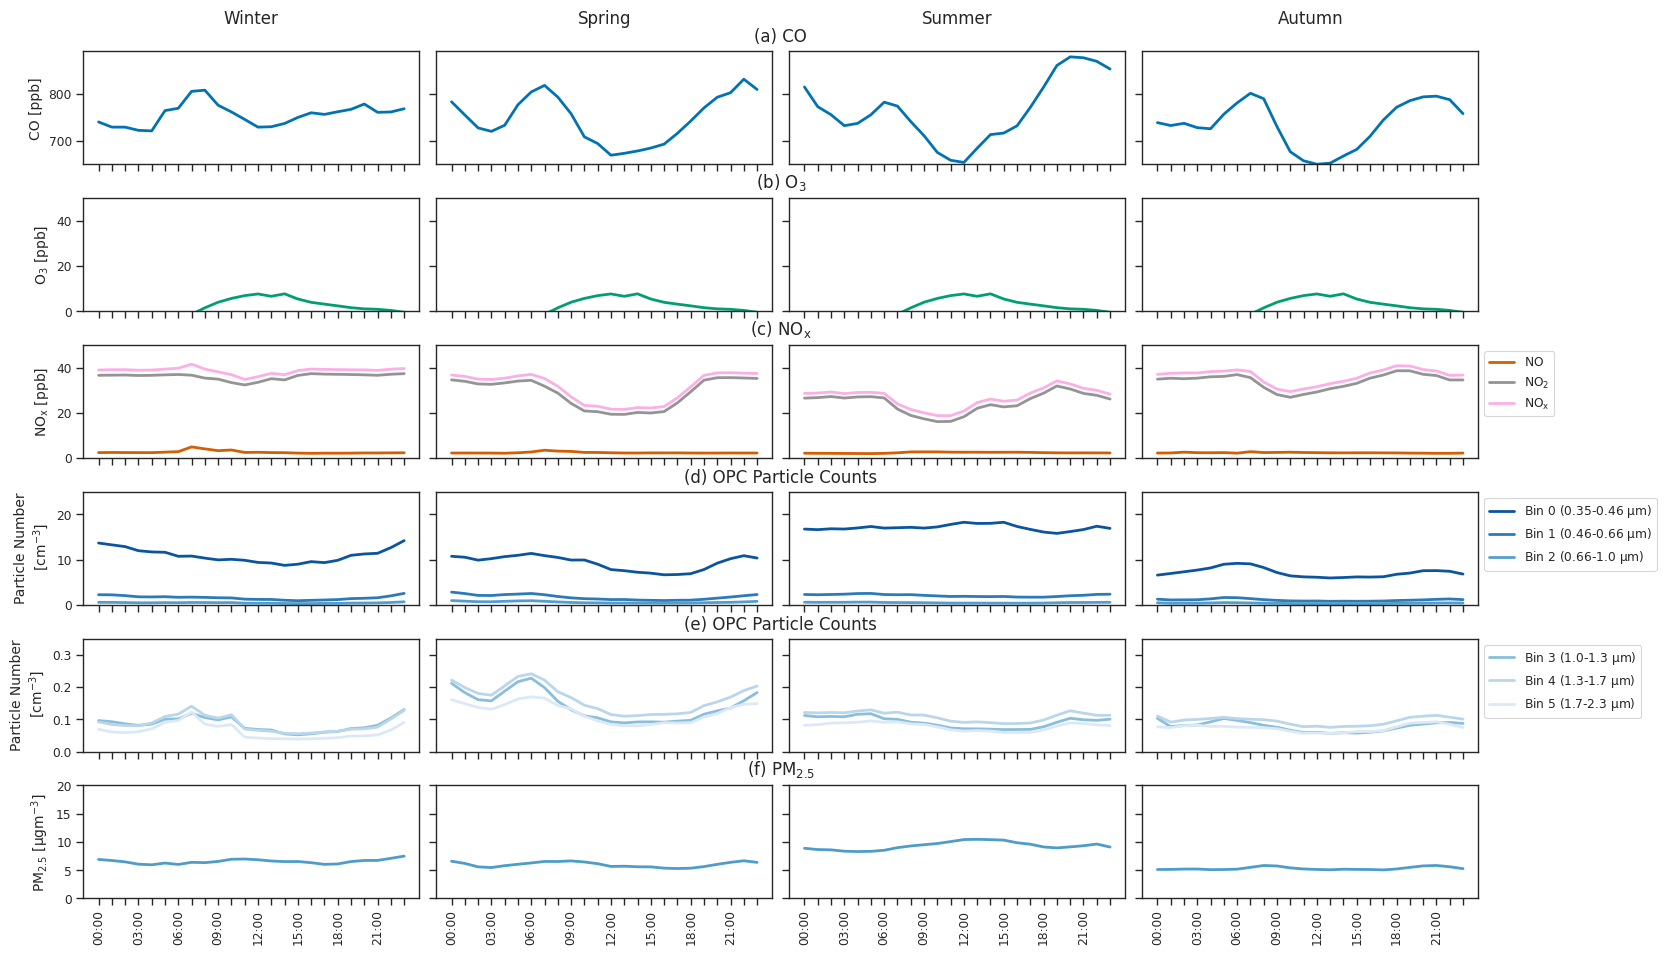

In [37]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

# fig.savefig('diurnal_by_season_MOD-00682.png')